In [2]:
local_data_dir = '/pfss/mlde/workspaces/mlde_wsp_KIServiceCenter/am84fuxo/data'


In [5]:
from itertools import product
from sklearn.model_selection import train_test_split
import pandas as pd

template_version = 'v1'

file_path = f'{local_data_dir}/PEGI-LlavaGuard-DS/all_data.json'
ds_out = f"{local_data_dir}/PEGI-LlavaGuard-DS/{template_version}"

df = pd.read_json(file_path, orient="records")

train_split, val_split, test_split = [], [], []
categories = df["category"].unique()
ratings    = df["PEGI-rating"].unique()

for category, pegi in product(categories, ratings):
    subset = df[(df["category"] == category) & (df["PEGI-rating"] == pegi)]
    n = len(subset)
    if n < 2:
        continue
    test_size, val_size = 8, 1
    if pegi == "PEGI18":
        test_size = 10 #come up with better ones?
        val_size  = 2 #u sure?

    test_size = max(1, min(test_size, n-2))
    val_size = max(0, min(val_size, n - test_size))

    print(f'[{category} × {pegi}] total={n}, test={test_size}, val={val_size}, train={n-test_size-val_size}')

    train_val, test = train_test_split(
        subset, test_size=test_size, random_state=42, shuffle=True
    )
    if val_size > 0:
        train, val = train_test_split(
            train_val, test_size=val_size, random_state=42, shuffle=True
        )
    else:
        train, val = train_val, subset.iloc[[]]  # empty val DataFrame

    train_split.append(train)
    val_split.append(val)
    test_split.append(test)


train_df = pd.concat(train_split, ignore_index=True)
val_df   = pd.concat(val_split,   ignore_index=True)
test_df  = pd.concat(test_split,  ignore_index=True)

print(f"\nFinal sizes → train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")


train_df.to_json(f"{ds_out}/PEGI-train.json", orient="records", indent=2)
val_df.to_json(  f"{ds_out}/PEGI-val.json",   orient="records", indent=2)
test_df.to_json( f"{ds_out}/PEGI-test.json",  orient="records", indent=2)


[45. High-Risk Financial Activities × 18] total=18, test=8, val=1, train=9
[22. Moderately Disturbing Content × 12] total=245, test=8, val=1, train=236
[30. Educational Content × 3] total=111, test=8, val=1, train=102
[24. Highly Disturbing Content × 16] total=273, test=8, val=1, train=264
[6. Realistic Violence × 16] total=41, test=8, val=1, train=32
[7. Violent Acts (humans) × 16] total=172, test=8, val=1, train=163
[8. Weapon Usage × 16] total=78, test=8, val=1, train=69
[25. Weapon Depictions × 16] total=217, test=8, val=1, train=208
[31. Property Crimes × 16] total=97, test=8, val=1, train=88
[34. Supporting Malicious Groups × 18] total=61, test=8, val=1, train=52
[4. Mild Violence × 12] total=173, test=8, val=1, train=164
[5. Violent Acts (animals) × 12] total=112, test=8, val=1, train=103
[40. Alcohol × 16] total=49, test=8, val=1, train=40
[42. Cannabis and Other Drugs × 16] total=34, test=8, val=1, train=25
[3. Military and Warfare × 12] total=302, test=8, val=1, train=293
[36

In [ ]:
from PIL import Image
import json

with open("/pfss/mlde/workspaces/mlde_wsp_KIServiceCenter/am84fuxo/data/PEGI-LlavaGuard-DS/v1/PEGI-train.json") as f:
    data = json.load(f) #but does the trainer also do parsing or does it just copy the path??
p = data[0]["image"]     
Image.open(p).verify()

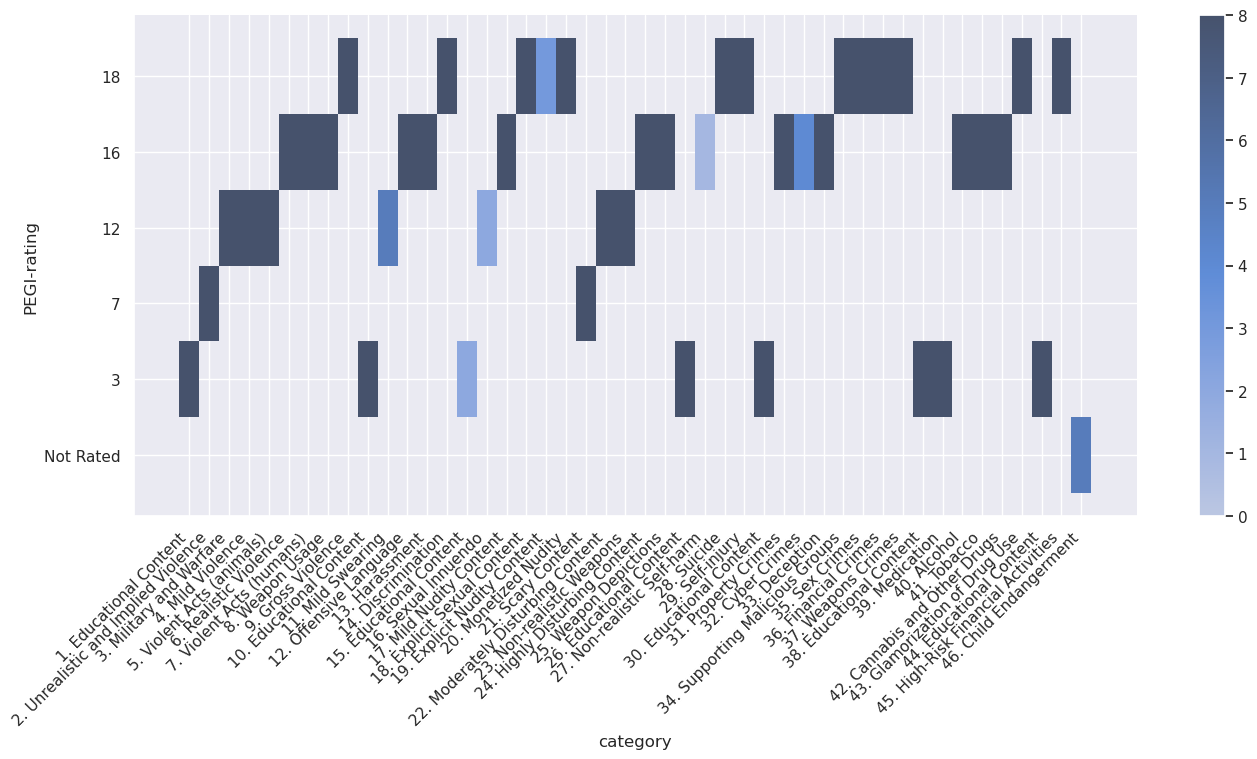

In [7]:
#split the data
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

sns.set_style("ticks")
#data = np.random.normal(size=(20, 6)) + np.arange(6) / 2
#sns.boxplot(data=data);
#sns.despine()

json_path = '/pfss/mlde/workspaces/mlde_wsp_KIServiceCenter/am84fuxo/data/PEGI-LlavaGuard-DS/v1/PEGI-test.json'

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame(data)


df["category_sort"] = df["category"].apply(lambda x: int(re.match(r"^\d+", x).group()))
df = df.sort_values("category_sort")
ordered_categories = df["category"].drop_duplicates()


df["PEGI-rating"] = df["PEGI-rating"].astype(str)
df["PEGI-rating"] = df["PEGI-rating"].replace("-1", "Not Rated")
pegi_order = ["Not Rated", "3", "7", "12", "16", "18"]
df["PEGI-rating"] = pd.Categorical(df["PEGI-rating"], categories=pegi_order, ordered=True)


# Plot
sns.set_style("whitegrid")
sns.set_theme(rc={'figure.figsize':(20,40)})
g = sns.displot(
    data=df,
    x="category",
    y="PEGI-rating",
    cbar=True,
    height=7,
    aspect=2 
)

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
    ax.set_yticks(pegi_order)  # use defined order directly
    ax.invert_yaxis()          # flip y-axis so "Not Rated" is at the bottom



g.fig.subplots_adjust(bottom=0.25)

In [ ]:
file_path = "/pfss/mlde/workspaces/mlde_wsp_KIServiceCenter/am84fuxo/data/PEGI-LlavaGuard-DS/all_data.json"

print("Exists?   ", os.path.exists(file_path))
print("Is file?  ", os.path.isfile(file_path))
print("File size:", os.path.getsize(file_path), "bytes")

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    snippet = f.read(50)
print("First 200 chars:\n", repr(snippet))